# 01-09 - Three Places, Three Radii

We answered one question in 01-04, for one door, at one distance. In this notebook we ask it twelve times, at three places on and around campus and at four distances each.

What comes back is more interesting than any single number, and it is the point of the whole precept: the answer to "is this a walkable place" depends more on the threshold we chose than on the place we asked about. That is not a flaw in the method. It is the method telling us something true, and learning to say it out loud is the difference between running an analysis and doing one.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")

In [2]:
food = gpd.read_file("data/princeton_food.geojson").to_crs("EPSG:26918")

landmarks = pd.read_csv("data/landmarks.csv")
places = gpd.GeoDataFrame(
    landmarks,
    geometry=gpd.points_from_xy(landmarks["lon"], landmarks["lat"]),
    crs="EPSG:4326",
).to_crs("EPSG:26918")

places[["id", "name"]]

,id,name
0,e225,Engineering Quad E225
1,nassau_hall,Nassau Hall
2,dinky,Princeton Station (Dinky)


## Asking the same question many times

Rather than writing the count out twelve times, we loop. For each place and each radius we build a row, and collect the rows into a table:

In [3]:
radii = [200, 400, 800, 1600]
rows = []

for _, place in places.iterrows():
    row = {"place": place["name"]}
    for radius in radii:
        row[f"{radius} m"] = int(food.within(place.geometry.buffer(radius)).sum())
    rows.append(row)

ladder = pd.DataFrame(rows).set_index("place")
ladder

,200 m,400 m,800 m,1600 m
place,,,,
Engineering Quad E225,0,20,54,90
Nassau Hall,12,55,71,79
Princeton Station (Dinky),2,2,32,78


Twelve numbers, and they repay a slow read.

Note the loop pattern, which is the one from the foundations series: build a dictionary per row, append it to a list, hand the list to `pd.DataFrame`. It is the most useful way to assemble results in Python, and it scales from three rows to three thousand without changing.

## Three findings

Read the table before reading on, and see what you notice.

**One. Our own classroom has nothing within 200 metres.** Zero. The nearest place to eat is 218 metres away, as the next cell confirms. So a walkability standard drawn at 200 metres classifies the Engineering Quad as having no food access at all, and a standard drawn at 250 metres does not. The conclusion flips on a threshold nobody in the room chose.

In [4]:
e225 = places[places["id"] == "e225"].geometry.iloc[0]
distances = food.distance(e225)
nearest = food.loc[distances.idxmin()]

print(f"nearest place to eat: {nearest['name']} at {distances.min():.0f} m")

nearest place to eat: Ficus at 218 m


**Two. The Dinky gains nothing between 200 and 400 metres.** Two places, then still two. Then it jumps to 32 by 800 metres.

That flat stretch is not noise, it is geography. The station sits on the far side of a stretch with nothing on it, so the circle grows for two hundred metres through empty ground. A straight-line buffer cannot see that the walk is along a road, and it cannot see the railway or the campus edge either. This is exactly the limitation that P07 exists to fix, by measuring along the street network instead.

**Three. At 1600 metres all three places converge, toward 90, 79 and 78.** Our entire dataset is 92 places, so by that radius every circle has swallowed most of the town and the differences between the three locations have almost vanished. Choose a large enough threshold and every place looks equally well served, which is a way of measuring nothing at all.

## Seeing it

The table is the finding. The picture is what makes somebody believe it:

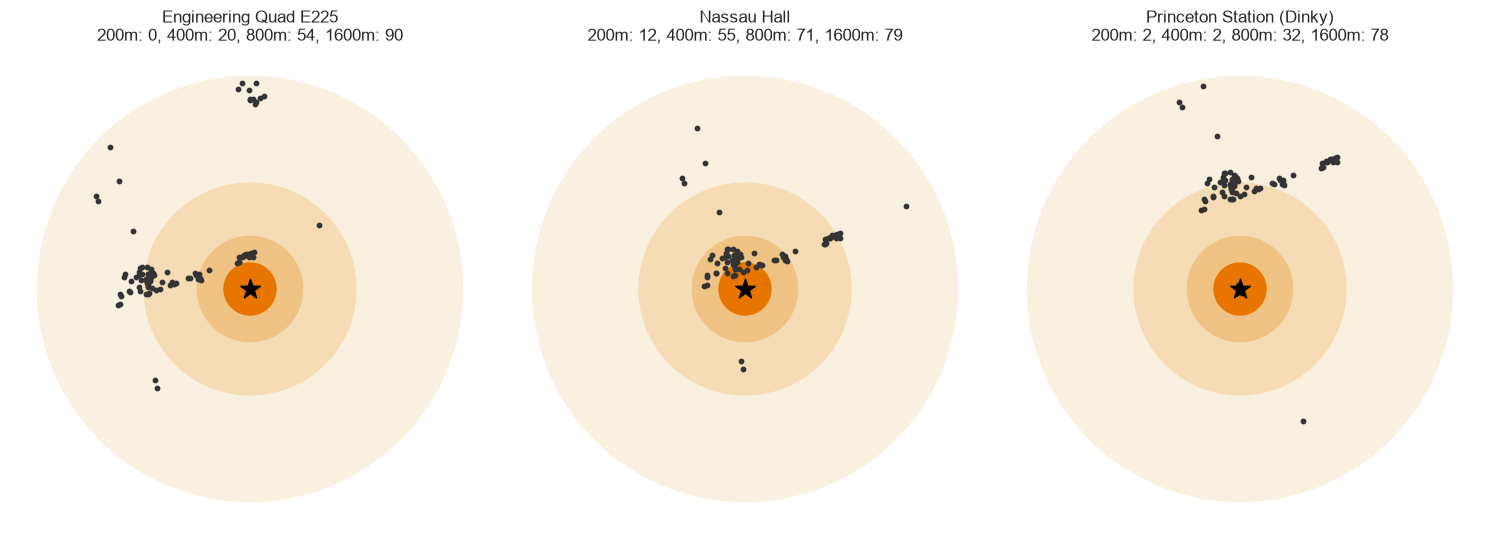

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

for axis, (_, place) in zip(axes, places.iterrows()):
    for radius, shade in zip(reversed(radii), ["#faf0e0", "#f5dcb4", "#efc383", "#e77500"]):
        gpd.GeoSeries([place.geometry.buffer(radius)], crs=food.crs).plot(
            ax=axis, color=shade, edgecolor="none")
    inside = food[food.within(place.geometry.buffer(1600))]
    inside.plot(ax=axis, color="#333333", markersize=10)
    gpd.GeoSeries([place.geometry], crs=food.crs).plot(
        ax=axis, color="black", marker="*", markersize=220)

    counts = ladder.loc[place["name"]]
    axis.set_title(f"{place['name']}\n" + ", ".join(f"{r}m: {counts[f'{r} m']}" for r in radii))
    bounds = place.geometry.buffer(1800).bounds
    axis.set_xlim(bounds[0], bounds[2])
    axis.set_ylim(bounds[1], bounds[3])
    axis.set_aspect("equal")
    axis.set_axis_off()

plt.tight_layout()

Three sets of rings, drawn at the same scale, with every place to eat inside the largest ring shown as a dot.

Nassau Hall sits in the middle of the cluster. E225 sits at its southern edge, close enough that the 400 metre ring reaches it and the 200 metre ring does not. The Dinky sits outside it, and its rings are mostly empty until the largest one arrives.

Note that all three stars are within a fifteen minute walk of each other. The differences in the table are not describing three different towns; they are describing three doors in one small town, and the numbers still range from 0 to 55.

## Saying it in a sentence

An analysis is finished when you can state it in a form somebody could act on, including its limits. Here is one:

> Within a 400 metre straight line, Nassau Hall has 55 places to eat, the Engineering Quad has 20, and Princeton station has 2. The differences are real but the threshold is doing much of the work: at 200 metres the Engineering Quad has none, and at 1600 metres all three sites have most of the town. Distances are straight lines rather than walking routes, so all three counts are optimistic, and the station is likely the most overstated because the walk from it is along a single road.

Note what that paragraph does. It gives the numbers, it names the choice that produced them, it says which direction the error runs, and it says which of the three results is least trustworthy and why. That is what the report to the municipality in December will need to do for a bigger question, and this is the smallest possible rehearsal of it.

## Check your understanding

1. A colleague reports that 55 places are within a short walk of Nassau Hall and 2 of the Dinky, concluding the station is poorly served. Give one reason that is fair and one reason it is an artefact of the method.
2. Why do all three rows converge at 1600 metres?
3. Which single number in the table would you put on a poster, and what sentence would go underneath it?
4. Our counts use straight lines. Would network distances make each number larger or smaller, and would it affect all three places equally?

## Where we are

That is the end of the P01 folder. You have made a map, checked whether it was the right place, computed an accessibility measure, audited an agent's version of it, opened up the table, understood coordinate systems, met the predicates, learned to read a picture honestly, and now turned one number into a finding with its limits stated.

Everything from here builds on this. In P02 we take Princeton's real open data into QGIS, and the three checks come with us.

## Further resources

Nothing in this course requires anything below.

What we computed is called a cumulative opportunities measure, and it is one of the oldest ideas in transport planning. Levinson and Wu give a readable modern overview in "Towards a general theory of access", Journal of Transport and Land Use, 2020, which is open access. For the network-distance version we come to in P07, the r5py documentation is the practical entry point: https://r5py.readthedocs.io.

The data is an OpenStreetMap extract, snapshot 2026-08-29, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright.